В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [25]:
df = pd.read_csv('sample_data/cars.csv')
df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [5]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [27]:
cat_columns = df.select_dtypes(include='object').columns
for col in cat_columns:
    unique_count = df[col].nunique()
    unique_values = df[col].unique()

    print(f"Колонка '{col}':")
    print(f"- Кількість унікальних значень: {unique_count}")
    print(f"- Значення: {unique_values}")
    print("--------------------------------")

Колонка 'Brand':
- Кількість унікальних значень: 11
- Значення: ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']
--------------------------------
Колонка 'Model':
- Кількість унікальних значень: 58
- Значення: ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']
--------------------------------
Колонка 'Fuel_Type':
- Кількість унікальних значень: 2
- Значення: ['Petrol' 'Diesel']
--------------------------------
Колонка 'Transmission':
- Кількість унікальних значень: 2
- Значення: ['Manual' 'Automatic']
-----

В наборі даних 8 числових і 5 категоріальних колонок з них:
  

*  2 бінарні (мають лише 2 значення: Fuel_Type, Transmission)
*  2 мультикатегоріальні (більше 2х значень) зі значеннями, для яких немає відношення порядку (Brand, Model)
*  1 колонка, в якій можна встановити відношення порядку (Owner_Type: First < Second < Third)





**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [28]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print(X_train.head())

X_train shape: (80, 12)
X_test shape: (20, 12)
y_train shape: (80,)
y_test shape: (20,)
    Car_ID       Brand  Model  Year  Kilometers_Driven Fuel_Type Transmission  \
83      84  Volkswagen  T-Roc  2019              22000    Petrol    Automatic   
55      56        Audi     A5  2018              28000    Diesel    Automatic   
26      27        Audi     A6  2018              28000    Petrol    Automatic   
54      55  Volkswagen  Vento  2017              32000    Petrol       Manual   
19      20    Mercedes    GLC  2017              26000    Petrol    Automatic   

   Owner_Type  Mileage  Engine  Power  Seats  
83     Second       18    1498    148      5  
55      First       17    1968    187      5  
26      First       15    1984    241      5  
54     Second       18    1598    103      5  
19     Second       12    1991    241      5  


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [29]:
fuel_mode = X_train['Fuel_Type'].mode()[0]
trans_mode = X_train['Transmission'].mode()[0]

print(f"Найпопулярніший тип пального: {fuel_mode}")
print(f"Найпопулярніша трансмісія: {trans_mode}")

def binary_encode(df, column, positive_value):
    return df[column].apply(lambda x: 1 if x == positive_value else 0)

X_train['Fuel_Type_Code'] = binary_encode(X_train, 'Fuel_Type', fuel_mode)
X_train['Transmission_Code'] = binary_encode(X_train, 'Transmission', trans_mode)

X_test['Fuel_Type_Code'] = binary_encode(X_test, 'Fuel_Type', fuel_mode)
X_test['Transmission_Code'] = binary_encode(X_test, 'Transmission', trans_mode)

print(X_train[['Fuel_Type', 'Fuel_Type_Code']].head())
print(X_train[['Transmission', 'Transmission_Code']].head())

Найпопулярніший тип пального: Petrol
Найпопулярніша трансмісія: Automatic
   Fuel_Type  Fuel_Type_Code
83    Petrol               1
55    Diesel               0
26    Petrol               1
54    Petrol               1
19    Petrol               1
   Transmission  Transmission_Code
83    Automatic                  1
55    Automatic                  1
26    Automatic                  1
54       Manual                  0
19    Automatic                  1


In [30]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe.fit(X_train[['Brand']])

ohe_feature_names = ohe.get_feature_names_out(['Brand'])
encoded_brand_train = ohe.transform(X_train[['Brand']])

X_train_brand_encoded = pd.DataFrame(encoded_brand_train, columns=ohe_feature_names, index=X_train.index)
X_train = pd.concat([X_train, X_train_brand_encoded], axis=1)

encoded_brand_test = ohe.transform(X_test[['Brand']])
X_test_brand_encoded = pd.DataFrame(encoded_brand_test, columns=ohe_feature_names, index=X_test.index)
X_test = pd.concat([X_test, X_test_brand_encoded], axis=1)

print(X_train[X_train.columns[X_train.columns.str.contains("Brand")]].head())

         Brand  Brand_Audi  Brand_BMW  Brand_Ford  Brand_Honda  Brand_Hyundai  \
83  Volkswagen         0.0        0.0         0.0          0.0            0.0   
55        Audi         1.0        0.0         0.0          0.0            0.0   
26        Audi         1.0        0.0         0.0          0.0            0.0   
54  Volkswagen         0.0        0.0         0.0          0.0            0.0   
19    Mercedes         0.0        0.0         0.0          0.0            0.0   

    Brand_Mahindra  Brand_Maruti  Brand_Mercedes  Brand_Tata  Brand_Toyota  \
83             0.0           0.0             0.0         0.0           0.0   
55             0.0           0.0             0.0         0.0           0.0   
26             0.0           0.0             0.0         0.0           0.0   
54             0.0           0.0             0.0         0.0           0.0   
19             0.0           0.0             1.0         0.0           0.0   

    Brand_Volkswagen  
83               1.0 

In [44]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

print(X_train[['Owner_Type', 'Owner_Type_Codes']].head())


   Owner_Type  Owner_Type_Codes
83     Second               1.0
55      First               0.0
26      First               0.0
54     Second               1.0
19     Second               1.0


In [33]:
print(X_train['Model'].value_counts())

Model
Altroz           3
Mustang          3
C-Class          3
T-Roc            2
A5               2
Q7               2
A3               2
XUV300           2
A6               2
Tiago            2
Fortuner         2
X3               2
S-Cross          2
GLE              2
Ameo             2
E-Class          2
Ranger           2
BR-V             2
EcoSport         2
Passat           2
Vitara           2
WR-V             2
Tigor            2
7 Series         2
X5               2
Verna            2
3 Series         2
Camry            2
GLC              1
Yaris            1
Vento            1
Innova           1
Innova Crysta    1
Elantra          1
Civic            1
Venue            1
Endeavour        1
Santro           1
Sonata           1
5 Series         1
Safari           1
Aspire           1
Thar             1
Corolla          1
Harrier          1
Nexon            1
GLA              1
Swift            1
Scorpio          1
Name: count, dtype: int64


*Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5*

Не дуже розумію як.. В наборі є Altroz, Mustang, C-Class у котрих є по 3 значення. То якщо скоротити до 3-5 то це значить оставити ці моделі де в групі >= 3 записи, а всі інші замінить на Other? і тоді буде як раз 4 унікальніх значення



Очікуваний результат після трансформацій:

In [32]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

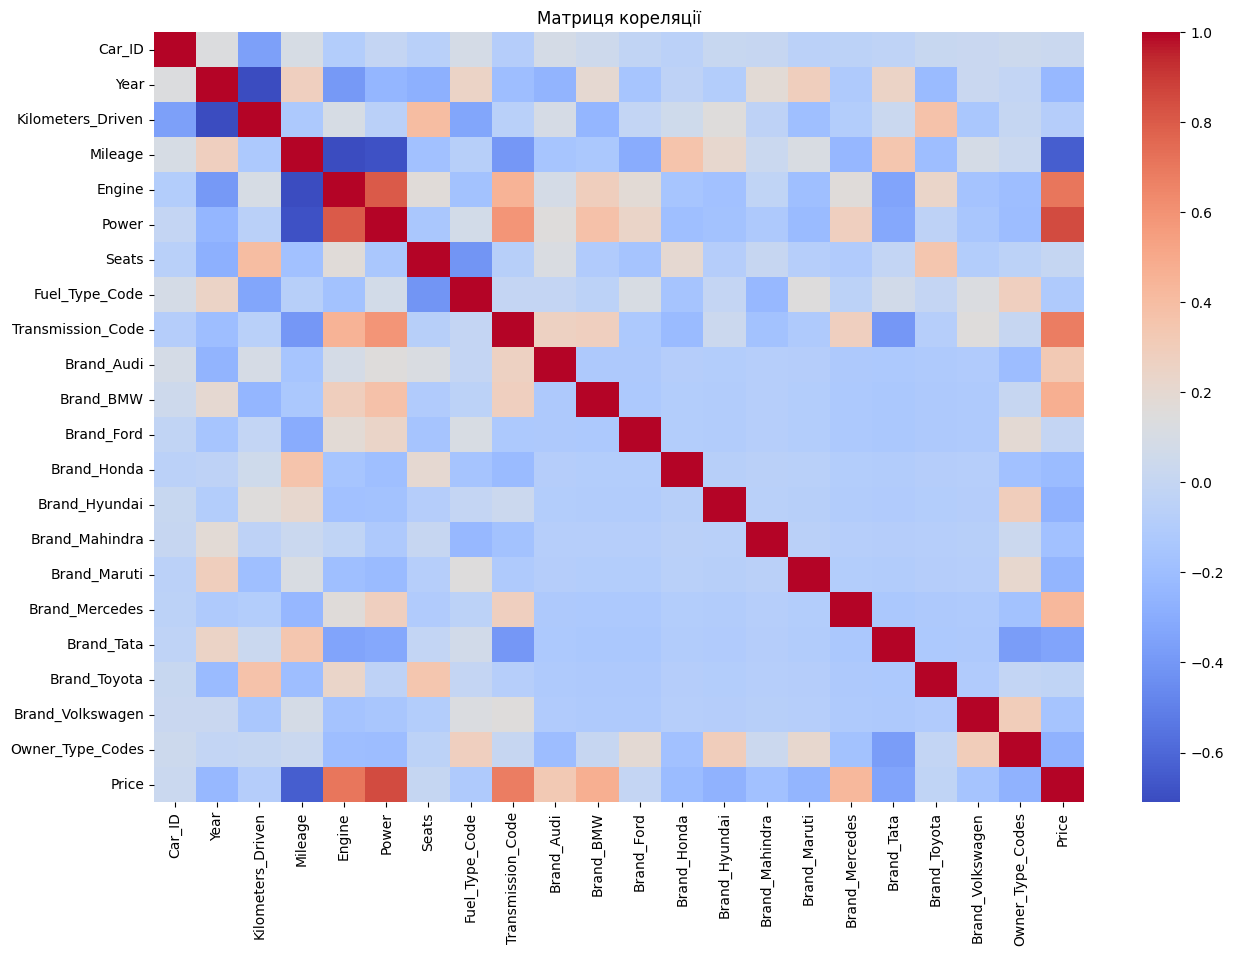

Кореляція з Price:
Price                1.000000
Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
Brand_BMW            0.477522
Brand_Mercedes       0.431606
Brand_Audi           0.328858
Car_ID               0.025560
Seats                0.000979
Brand_Ford          -0.004592
Brand_Toyota        -0.023778
Kilometers_Driven   -0.083951
Fuel_Type_Code      -0.110782
Brand_Volkswagen    -0.158742
Brand_Mahindra      -0.178627
Brand_Honda         -0.209779
Year                -0.233769
Brand_Maruti        -0.249737
Brand_Hyundai       -0.263022
Owner_Type_Codes    -0.265537
Brand_Tata          -0.341815
Mileage             -0.638404
Name: Price, dtype: float64

Ознаки з сильною кореляцією (|corr| > 0.5):
Price                1.000000
Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
Mileage             -0.638404
Name: Price, dtype: float64


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

X_train_numeric = X_train.select_dtypes(include=['number'])
full_train_data = pd.concat([X_train_numeric, y_train], axis=1)
corr_matrix = full_train_data.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Матриця кореляції')
plt.show()

print("Кореляція з Price:")
price_correlations = corr_matrix['Price'].sort_values(ascending=False)
print(price_correlations)

high_corr_features = price_correlations[abs(price_correlations) > 0.5]
print("\nОзнаки з сильною кореляцією (|corr| > 0.5):")
print(high_corr_features)

**Power (0.849137)**: Дуже сильна позитивна кореляція. Чим потужніший автомобіль, тим він дорожчий

**Engine (0.710561)**: більший двигун -> вища ціна.

**Transmission_Code (0.680731)**: тип коробки передач (Автомат vs Механіка) суттєво впливає на вартість. Aвтоматична коробка асоціюється з вищою ціною.

Mileage (-0.638404): Сильна негативна кореляція. Чим економічніше авто тим воно дешевше -> менш потужне.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

RMSE на тренувальній вибірці: 210293.58
RMSE на тестовій вибірці: 258181.56


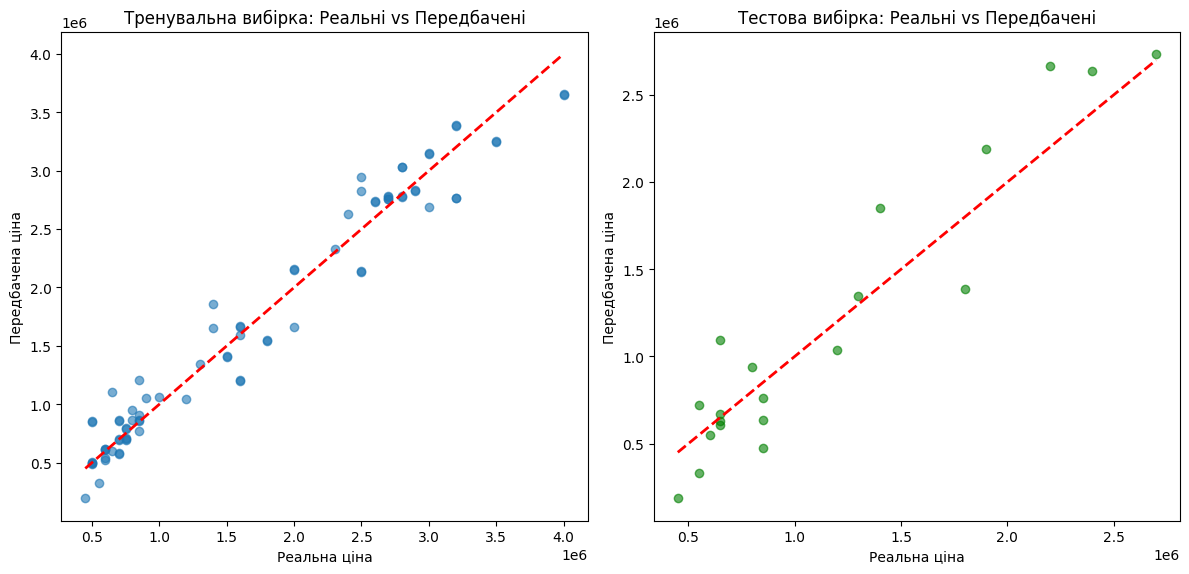

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

model = LinearRegression()
model.fit(X_train_numeric, y_train)

train_preds = model.predict(X_train_numeric)
test_preds = model.predict(X_test_numeric)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print(f"RMSE на тренувальній вибірці: {train_rmse:.2f}")
print(f"RMSE на тестовій вибірці: {test_rmse:.2f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_train, train_preds, alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')
plt.title('Тренувальна вибірка: Реальні vs Передбачені')

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_preds, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')
plt.title('Тестова вибірка: Реальні vs Передбачені')

plt.tight_layout()
plt.show()

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [43]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_numeric),
                              columns=X_train_numeric.columns,
                              index=X_train_numeric.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test_numeric),
                             columns=X_test_numeric.columns,
                             index=X_test_numeric.index)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Ознака': X_train_numeric.columns,
    'Коефіцієнт (Вага)': model_scaled.coef_,
    'Абсолютна вага': abs(model_scaled.coef_)
})

coef_df_sorted = coef_df.sort_values(by='Абсолютна вага', ascending=False)

print("Топ впливових ознак:")
print(coef_df_sorted)

Топ впливових ознак:
               Ознака  Коефіцієнт (Вага)  Абсолютна вага
5               Power      496769.214899   496769.214899
16     Brand_Mercedes      210048.781148   210048.781148
10          Brand_BMW      208407.313783   208407.313783
9          Brand_Audi      205600.147769   205600.147769
7      Fuel_Type_Code     -183848.018909   183848.018909
13      Brand_Hyundai     -152304.863911   152304.863911
14     Brand_Mahindra     -140945.162904   140945.162904
3             Mileage     -131715.512030   131715.512030
11         Brand_Ford     -118209.450311   118209.450311
8   Transmission_Code      116693.768206   116693.768206
15       Brand_Maruti     -112259.967020   112259.967020
2   Kilometers_Driven      -94398.721486    94398.721486
19   Brand_Volkswagen      -92968.260065    92968.260065
17         Brand_Tata      -65996.246972    65996.246972
12        Brand_Honda      -62753.005386    62753.005386
20   Owner_Type_Codes       42344.952815    42344.952815
4         

1. Найвпливовіші колонки (Топ-3 за абсолютною вагою):

**Power (496769)**: Це найважливіша ознака. Коефіцієнт позитивний. Зі збільшенням потужності ціна зростає найсильніше.


Brand_Mercedes, Brand_BMW, Brand_Audi (205600 - 210048): Преміальні бренди сильно підвищують ціну.


Fuel_Type_Code (-183848): Сильний негативний коефіцієнт. Оскільки ми кодували популярне паливо Petrol як 1, а Diesel як 0 це показує сильну різницю в ціні між типами двигунів.


2. Напрям дії:

Power (+): Більше потужності = Вища ціна.

Mileage (-131715): Негативний коефіцієнт. Чим вищий Mileage, тим нижча ціна.

Kilometers_Driven (-94398): Негативний коефіцієнт. Чим більше машина проїхала, тим вона дешевша.

Owner_Type_Codes (42344): Позитивний. Більше власників = дорожче?

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [46]:
import statsmodels.api as sm


X_train_scaled_const = sm.add_constant(X_train_scaled)
model_sm = sm.OLS(y_train, X_train_scaled_const).fit()
print(model_sm.summary())

p_values = model_sm.pvalues
print("\nСтатистично значущі ознаки (p-value < 0.05):")
significant_features = p_values[p_values < 0.05].index.tolist()
print(significant_features)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.01e-33
Time:                        13:09:23   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.74e+0

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [47]:
significant_cols = ['const', 'Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code',
                   'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai',
                   'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Volkswagen']

X_train_sig = X_train_scaled_const[significant_cols]

model_sig = sm.OLS(y_train, X_train_sig).fit()

print(model_sig.summary())

print(f"\nНовий R-squared: {model_sig.rsquared:.4f}")
print(f"Новий Adj. R-squared: {model_sig.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.12e-39
Time:                        13:11:38   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

Висновки:
R-squared	      0.959 (всі ознаки)	--> 0.9514 (значущі)
Adj. R-squared	0.945 (всі ознаки)	--> 0.9427 (значущі)

Зміна показників незначна. R-squared впав лише на 0.008, а Adj. R-squared змінився ще менше.

Це значить що можно викинути ці ознаки (Year, Kilometers_Driven, Engine, Seats, Owner_Type, деякі бренди), і якість передбачення не погіршиться. Ті ознаки дійсно були зайвими.



**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [49]:
p_values = model_sm.pvalues
features_025 = p_values[p_values < 0.25].index.tolist()

print("Ознаки, відібрані за критерієм p < 0.25:")
print(features_025)

X_train_025 = X_train_scaled_const[features_025]

model_10 = sm.OLS(y_train, X_train_025).fit()

print(model_10.summary())

print("\n--- Порівняння ---")
print(f"Модель 8 (Всі ознаки):   R2 = {model_sm.rsquared:.4f}, Adj. R2 = {model_sm.rsquared_adj:.4f}")
print(f"Модель 9 (p < 0.05):     R2 = 0.9514, Adj. R2 = 0.9427 ")
print(f"Модель 10 (p < 0.25):    R2 = {model_10.rsquared:.4f}, Adj. R2 = {model_10.rsquared_adj:.4f}")

Ознаки, відібрані за критерієм p < 0.25:
['const', 'Kilometers_Driven', 'Mileage', 'Power', 'Fuel_Type_Code', 'Transmission_Code', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes', 'Brand_Tata', 'Brand_Volkswagen']
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.85e-38
Time:                        13:20:10   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         

(p < 0.25) виглядає найкращою бо R2 = 0.9480 виріс трохи, навіть більше ніж у повній моделі. Тож якість ознаки які ми викинули в (p < 0.05) мають вплив